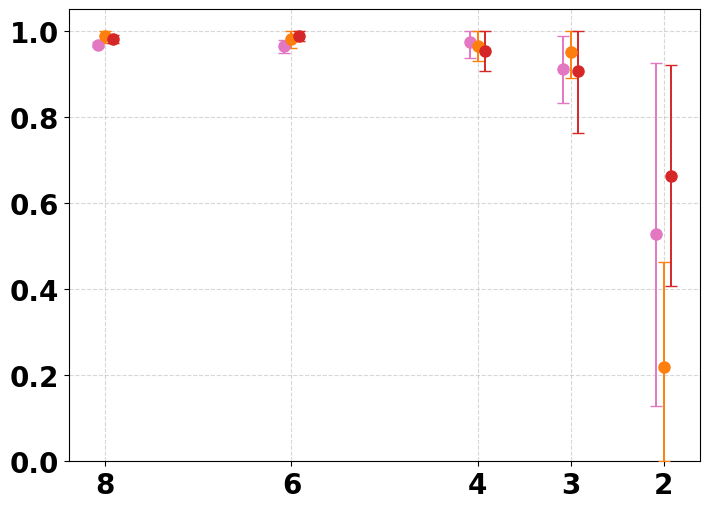

In [17]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import numpy as np

# --- CSVをすべて読み込み ---
csv_files = glob.glob("/work/robomimic/csv/eval/lift/quantize/weight/unit*.csv")

def extract_bit(filename: str):
    match = re.search(r"quantized_(\d+)bit", filename)
    return int(match.group(1)) if match else None

df_list = []

for file in csv_files:
    bit = extract_bit(file)
    if bit is None:
        continue
    df = pd.read_csv(file)
    df["bit"] = bit
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)

def extract_base_model(name: str):
    match = re.match(r"(.*)_seed\d+", name)
    return match.group(1) if match else name

df_all["base_model"] = df_all["name"].apply(extract_base_model)

# --- 集計 ---
df_agg = (
    df_all.groupby(["base_model", "bit"])["success_rate"]
          .agg(["mean", "std"])
          .reset_index()
)

df_agg["std"] = df_agg["std"].fillna(0)

# --- 描画設定 ---
custom_colors = {
    "ncp_u128_best": "#e377c2",
    "ncp_u256_best": "#ff7f0e",
    "ncp_u512_best": "#d62728",
}

offsets = {
    "ncp_u128_best":  0.08,
    "ncp_u256_best":  0.00,
    "ncp_u512_best":  -0.08,
}


plt.figure(figsize=(7.2, 5.2))

for base_model, df_m in df_agg.groupby("base_model"):
    df_m = df_m.sort_values("bit", ascending=False)

    bits  = df_m["bit"].values
    means = df_m["mean"].values
    stds  = df_m["std"].values

    lower = np.maximum(means - stds, 0)
    upper = np.minimum(means + stds, 1)

    offset = offsets.get(base_model, 0.0)
    x = bits + offset
    color = custom_colors.get(base_model, "gray")

    # --- 点 + エラーバー（主役） ---
    plt.errorbar(
        x,
        means,
        yerr=[means - lower, upper - means],
        fmt="o",
        color=color,
        markersize=8,
        elinewidth=1.4,
        capsize=4,
        zorder=10,
        label=base_model.replace("_best", "")
    )


# --- 軸・スタイル ---
plt.tick_params(axis="both", labelsize=20)
for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight("bold")

plt.ylim(0, 1.05)
plt.gca().invert_xaxis()
plt.xticks(sorted(df_agg["bit"].unique(), reverse=True))

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


   base_model  bit      mean       std
0     unit128    2  0.853333  0.085049
1     unit256    2  0.930000  0.036056
2     unit512    2  0.950000  0.026458
3     unit256    3  0.980000  0.026458
4     unit512    3  0.983333  0.011547
5     unit128    3  0.966667  0.015275
6     unit256    4  0.986667  0.015275
7     unit128    4  0.953333  0.005774
8     unit512    4  0.970000  0.020000
9     unit128    6  0.970000  0.020000
10    unit512    6  0.980000  0.020000
11    unit256    6  0.986667  0.023094
12    unit128    8  0.973333  0.020817
13    unit256    8  0.986667  0.023094
14    unit512    8  0.976667  0.015275


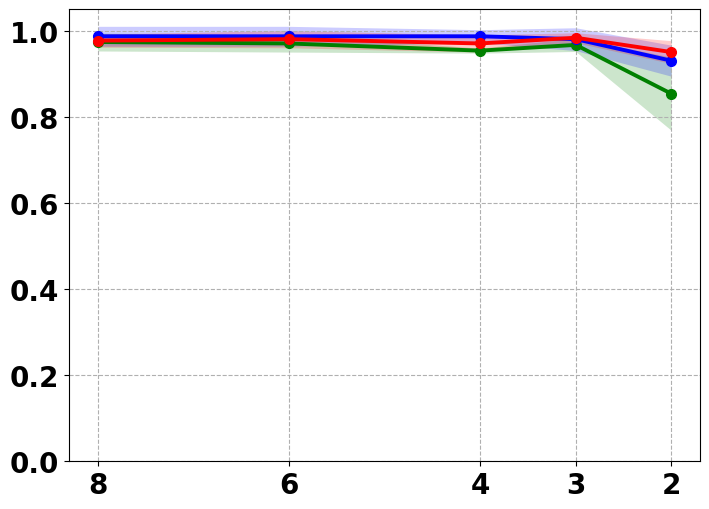

In [10]:
# Digital Fixed Params Quantization (2bit, 3bit, 4bit, 6bit, 8bit)
import pandas as pd
import glob
import re

# --- CSV をすべて読み込み ---
csv_files = glob.glob(
    "/work/robomimic/csv/eval/lift/quantize/digital/RRAM/RRAMunit*.csv"
)

def extract_bit(filename: str):
    """
    RRAMunit128_quantized_2bit.csv -> 2
    """
    match = re.search(r"quantized_(\d+)bit", filename)
    return int(match.group(1)) if match else None

def extract_base_model_from_filename(filename: str):
    """
    RRAMunit128_quantized_2bit.csv -> unit128
    """
    match = re.search(r"RRAM(unit\d+)", filename)
    return match.group(1) if match else None

df_list = []

for file in csv_files:
    bit = extract_bit(file)
    base_model = extract_base_model_from_filename(file)

    if bit is None or base_model is None:
        continue

    df = pd.read_csv(file)
    df["bit"] = bit
    df["base_model"] = base_model
    df_list.append(df)

# --- 全部結合 ---
df_all = pd.concat(df_list, ignore_index=True)

# --- base_model × bit ごとの success_rate mean / std ---
df_agg = (
    df_all
    .groupby(["base_model", "bit"])["success_rate"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("bit")
    .reset_index(drop=True)
)

print(df_agg)

# --- カスタムカラーパレット ---
custom_colors = {
    "unit128": "green",
    "unit256": "blue",
    "unit512": "red",
}

plt.figure(figsize=(7.2, 5.2))

for base_model, df_m in df_agg.groupby("base_model"):
    color = custom_colors.get(base_model, "gray")

    # ★ bit を必ずソート（invert_xaxis + fill_between 対策）
    df_m = df_m.sort_values("bit", ascending=False)

    bits  = df_m["bit"].values
    means = df_m["mean"].values
    stds  = df_m["std"].values

    # --- 標準偏差帯（極薄・背景） ---
    plt.fill_between(
        bits,
        means - stds,
        means + stds,
        color=color,
        alpha=0.20,
        linewidth=0,
        zorder=1
    )

    # --- 平均線（主役） ---
    plt.plot(
        bits,
        means,
        marker="o",
        color=color,
        linewidth=2.8,
        markersize=7,
        zorder=10,
        label=base_model
    )

# --- 軸・スタイル ---
plt.tick_params(axis="both", labelsize=20, labelfontfamily="DejaVu Sans")

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight("bold")

plt.ylim(0, 1.05)
plt.gca().invert_xaxis()
plt.xticks(sorted(df_agg["bit"].unique(), reverse=True))

plt.grid(True, which="major", linestyle="--")

plt.tight_layout()
plt.show()



   base_model  bit      mean       std
0     unit128    2  0.530000  0.182483
1     unit256    2  0.783333  0.176163
2     unit512    2  0.736667  0.213854
3     unit256    3  0.926667  0.005774
4     unit512    3  0.880000  0.045826
5     unit128    3  0.873333  0.040415
6     unit256    4  0.950000  0.051962
7     unit128    4  0.946667  0.028868
8     unit512    4  0.963333  0.035119
9     unit128    6  0.976667  0.011547
10    unit512    6  0.976667  0.020817
11    unit256    6  0.983333  0.020817
12    unit128    8  0.970000  0.017321
13    unit256    8  0.990000  0.017321
14    unit512    8  0.986667  0.011547


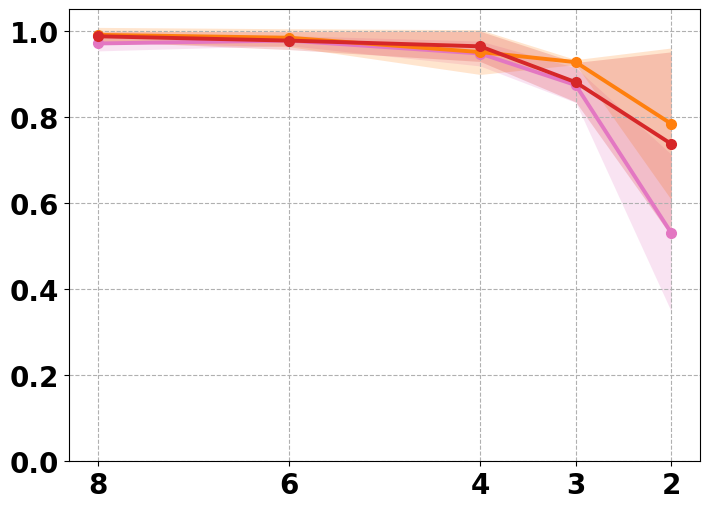

In [8]:
# Digital Variable Params Quantization (2bit, 3bit, 4bit, 6bit, 8bit)
import pandas as pd
import glob
import re

# --- CSV をすべて読み込み ---
csv_files = glob.glob(
    "/work/robomimic/csv/eval/lift/quantize/digital/SRAM/SRAMunit*.csv"
)

def extract_bit(filename: str):
    """
    SRAMunit128_quantized_2bit.csv -> 2
    """
    match = re.search(r"quantized_(\d+)bit", filename)
    return int(match.group(1)) if match else None

def extract_base_model_from_filename(filename: str):
    """
    SRAMunit128_quantized_2bit.csv -> unit128
    """
    match = re.search(r"SRAM(unit\d+)", filename)
    return match.group(1) if match else None

df_list = []

for file in csv_files:
    bit = extract_bit(file)
    base_model = extract_base_model_from_filename(file)

    if bit is None or base_model is None:
        continue

    df = pd.read_csv(file)
    df["bit"] = bit
    df["base_model"] = base_model
    df_list.append(df)

# --- 全部結合 ---
df_all = pd.concat(df_list, ignore_index=True)

# --- base_model × bit ごとの success_rate mean / std ---
df_agg = (
    df_all
    .groupby(["base_model", "bit"])["success_rate"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("bit")
    .reset_index(drop=True)
)

print(df_agg)

# --- カスタムカラーパレット ---
custom_colors = {
    "unit128": "#e377c2",
    "unit256": "#ff7f0e",
    "unit512": "#d62728",
}

plt.figure(figsize=(7.2, 5.2))

for base_model, df_m in df_agg.groupby("base_model"):
    color = custom_colors.get(base_model, "gray")

    # ★ bit を必ずソート（invert_xaxis + fill_between 対策）
    df_m = df_m.sort_values("bit", ascending=False)

    bits  = df_m["bit"].values
    means = df_m["mean"].values
    stds  = df_m["std"].values

    # --- 標準偏差帯（極薄・背景） ---
    plt.fill_between(
        bits,
        means - stds,
        means + stds,
        color=color,
        alpha=0.20,     # 帯は存在を感じる程度
        linewidth=0,
        zorder=1
    )

    # --- 平均線（主役） ---
    plt.plot(
        bits,
        means,
        marker="o",
        color=color,
        linewidth=2.8,
        markersize=7,
        zorder=10,
        label=base_model
    )

# --- 軸・スタイル ---
plt.tick_params(axis="both", labelsize=20, labelfontfamily="DejaVu Sans")

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight("bold")

plt.ylim(0, 1.05)
plt.gca().invert_xaxis()
plt.xticks(sorted(df_agg["bit"].unique(), reverse=True))

plt.grid(True, which="major", linestyle="--")

plt.tight_layout()
plt.show()
